In [15]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


def visualize_qps(csv_path: Path, time_bucket_ms: int = 10000, y_limit: float = 170, save_name: str = None):
    """
    Generate a plot showing QPS for the first 35 minutes from an LLM inference request trace.
    """
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Convert arrived_at to microseconds relative to first request
    start_time = df['arrived_at'].min()
    df['timestamp_us'] = (df['arrived_at'] - start_time) * 1e6

    # Compute time bucket for each row
    df['time_bucket'] = (df['timestamp_us'] // (time_bucket_ms * 1000)).astype(int)

    # Aggregate QPS
    agg = df.groupby('time_bucket').agg(
        qps=('timestamp_us', 'count')
    ).reset_index()

    # Fill in missing time buckets with zeroes
    all_buckets = pd.DataFrame({
        'time_bucket': np.arange(df['time_bucket'].min(), df['time_bucket'].max() + 1)
    })
    agg = pd.merge(all_buckets, agg, on='time_bucket', how='left').fillna(0)

    agg['qps'] = agg['qps'] / (time_bucket_ms / 1000.0)

    # Filter data for the first 35 minutes
    max_time_bucket = (35 * 60 * 1000) // time_bucket_ms  # 35 minutes in number of buckets
    agg = agg[agg['time_bucket'] <= max_time_bucket]



    # Plot QPS using seaborn
    plt.figure(figsize=(9.6, 4.0), constrained_layout=True)
    sns.set_theme(context="paper", style="whitegrid")
    ax = sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['qps'])
    ax.set_xlabel('Time (minutes)', fontsize=18)
    ax.set_ylabel('Requests per Second (RPS)', fontsize=18)
    ax.set_ylim(0, y_limit)
    ax.set_xlim(0, 35)
    # Add horizontal bars and annotate average QPS for 5-minute chunks
    chunk_size = (5 * 60 * 1000) // time_bucket_ms  # 5 minutes in number of buckets
    for i in range(0, max_time_bucket, chunk_size):
        chunk = agg[(agg['time_bucket'] >= i) & (agg['time_bucket'] < i + chunk_size)]
        if not chunk.empty:
            avg_qps = chunk['qps'].mean()
            ax.axvline(x=i * (time_bucket_ms / 1000.0) / 60, color='black', linestyle='--', alpha=1.0)
            ax.text((i + chunk_size / 2) * (time_bucket_ms / 1000.0) / 60, 
                    max(agg['qps']) * 0.1, 
                    f'{avg_qps:.1f}', 
                    ha='center', 
                    va='center', 
                    fontsize=18, 
                    color='black', 
                    fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=18)
    plt.show()
    if save_name:
        plt.tight_layout()
        ax.get_figure().savefig(save_name, format="pdf")


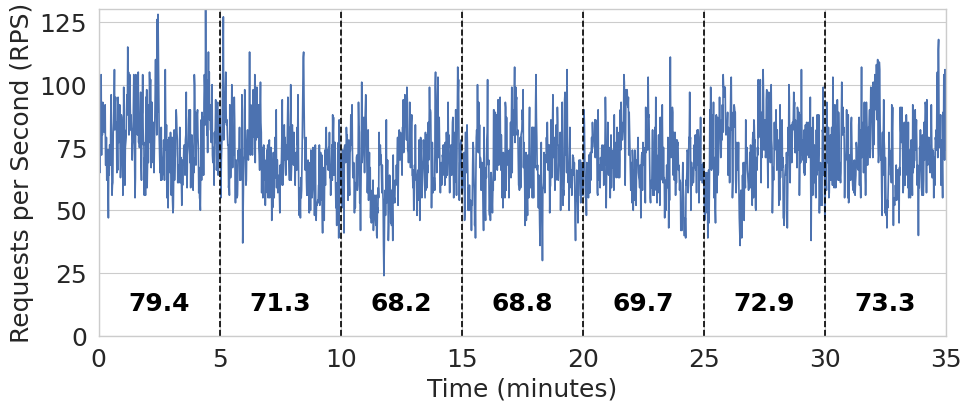

<Figure size 640x480 with 0 Axes>

In [16]:
visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps93.46_req-cnt200000.csv'), time_bucket_ms=1000, y_limit=130, save_name="figs/plot_8.1b_rps_67p.pdf")

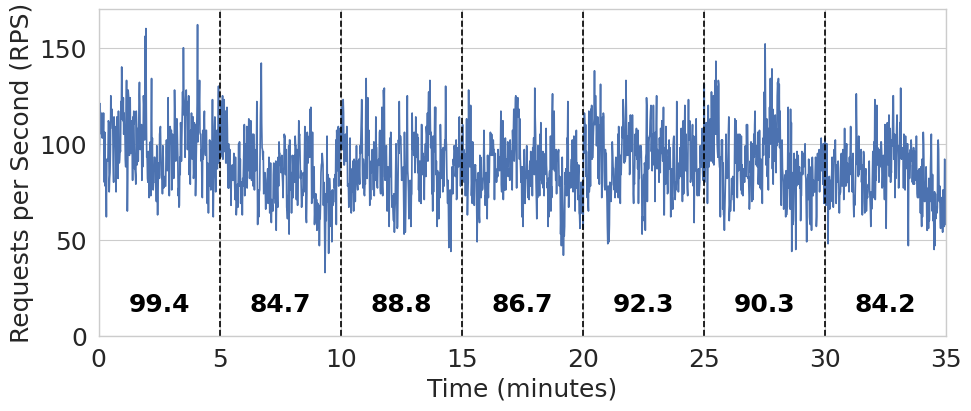

<Figure size 640x480 with 0 Axes>

In [17]:

visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), time_bucket_ms=1000, y_limit=170, save_name="figs/plot_8.1b_rps_85p.pdf")